In [1]:
import numpy as np
from desc.objectives import TrappedResonance
from desc.equilibrium import Equilibrium
import matplotlib.pyplot as plt

In [ ]:
eq = Equilibrium.load("wout_v20250319_v3_LowShear_000_000000_desc.h5")

num_eta = 20
Ekin_frac = 1
s_min = 0.01
s_max = 0.9
pp = 0
qq = 1

data = np.load("wout_v20250319_v3_LowShear_000_000000_desc_poincare_data_Bcrit_4.98.npz",allow_pickle=True)

Bcrit = 1/data['lam'][()]

s_prof = np.linspace(s_min, s_max, 20)

rhos = np.sqrt(s_prof)

obj = TrappedResonance(
    eq, rho=rhos, num_eta=num_eta, M=0, N=1,
    pitch_invs=np.array([Bcrit]), DEBUG=True,
    pitch_method=2, num_well=1, num_transit=2,
    knots_per_transit=100, num_quad=48, KE_frac=Ekin_frac,
    weight_method="bump", Delta_Omega=0.002
)
obj.build()
val = obj.compute(eq.params_dict)

Precomputing transforms


In [10]:
np.savez("desc_debug.npz", val=val)
val = np.load("desc_debug.npz",allow_pickle=True)['val'][()]
valid = np.isfinite(val['Delta_s'][0,0,:])
Delta_s = val['Delta_s'][0,0,valid]
s_res = val['s_res'][0,0,valid]
p_arr = val['p_arr'][valid]
q_arr = val['q_arr'][valid]
Omega = val['Omega'][:,0,0]
res_weight = val['res_weight'][:,0,0,:] #(rho, pitch, well, res)

In [15]:
freq_data = np.load("wout_v20250319_v3_LowShear_000_000000_desc_trapped_frequencies.npz",allow_pickle=True)

omega_b = freq_data['omega_b_prof'][()]
omega_alpha = freq_data['omega_alpha_prof'][()]

Omega_firm3d = omega_alpha/omega_b
lam_values = freq_data['lam_values'][()]
lam_index = np.argmin(np.abs(1/lam_values - Bcrit))
Omega_firm3d = Omega_firm3d[lam_index]
s_firm3d = freq_data['s_prof'][()][lam_index]

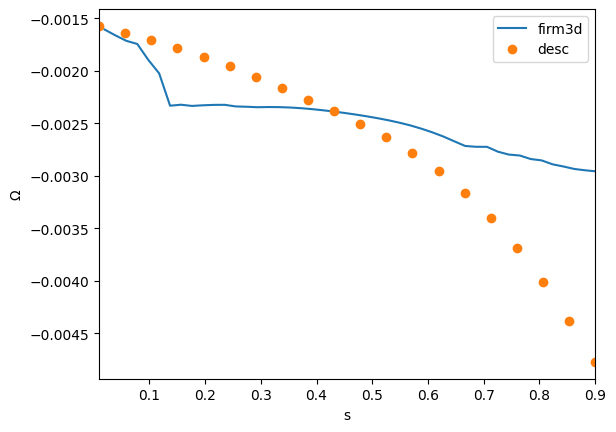

In [14]:
plt.figure()
plt.plot(s_firm3d,-Omega_firm3d,'-',label='firm3d')
plt.plot(s_prof,Omega,'o',label='desc')
plt.xlabel('s')
plt.ylabel('$\Omega$')
plt.xlim(s_min,s_max)
plt.legend()
plt.show()

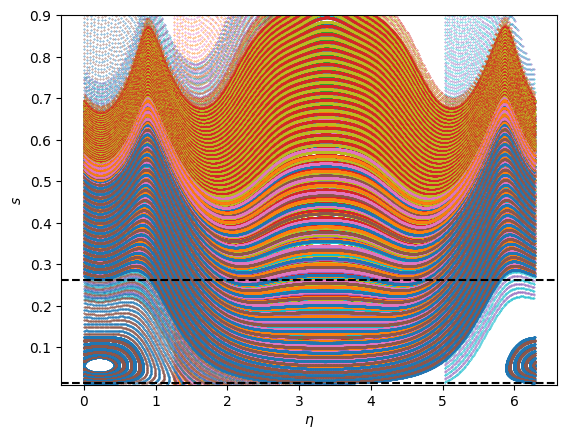

In [ ]:
s_poinc = data['s_all']
etas_poinc = data['etas_all']

plt.figure()
for i in range(len(s_poinc)):
    plt.scatter(np.mod(etas_poinc[i],2*np.pi),s_poinc[i],s=0.1)
plt.ylim(s_min,s_max)
plt.axhline(s_res[(p_arr == pp) & (q_arr == qq)], color='k', linestyle='--')
plt.axhline(s_res[(p_arr == pp) & (q_arr == qq)] + 0.5*Delta_s[(p_arr == pp) & (q_arr == qq)], color='k', linestyle='--')
plt.axhline(s_res[(p_arr == pp) & (q_arr == qq)] - 0.5*Delta_s[(p_arr == pp) & (q_arr == qq)], color='k', linestyle='--')
plt.xlabel('$\eta$')
plt.ylabel('$s$')
plt.show()